In [1]:
import os

### Verifier l'équilibre des classes

In [2]:
DATA_SET_PATH= "data_set"

fire_count= len(os.listdir(os.path.join(DATA_SET_PATH, "Fire")))
no_fire_count= len(os.listdir(os.path.join(DATA_SET_PATH, "No_Fire")))

print(f"nombre d'image au il ya le feu :  {fire_count}")
print(f"nombre d'image  ou ya pas de feu : {no_fire_count}")
print(f"nombre total d'image est : {fire_count + no_fire_count}")

nombre d'image au il ya le feu :  556
nombre d'image  ou ya pas de feu : 556
nombre total d'image est : 1112


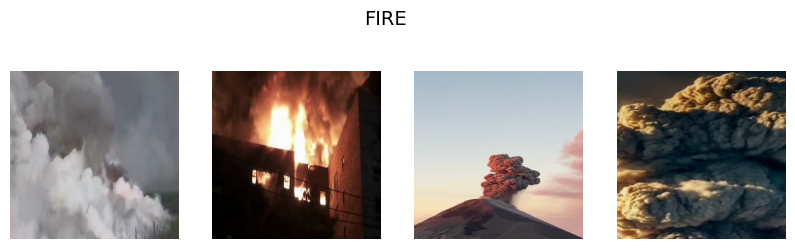

In [3]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def show_images(folder, title, n=4):
    imgs = random.sample(os.listdir(folder), min(n, len(os.listdir(folder))))
    
    plt.figure(figsize=(10,3))
    for i, img_name in enumerate(imgs):
        img = Image.open(os.path.join(folder, img_name))
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(title, fontsize=14)
    plt.show()

show_images(os.path.join(DATA_SET_PATH, "Fire"), "FIRE")


### Redimensioner et normaliser les images


In [4]:
from torchvision import transforms

transform_basic = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [5]:
# TEST
from PIL import Image
import matplotlib.pyplot as plt

img_path = "data_set/Fire/" + os.listdir("data_set/Fire")[0]
img = Image.open(img_path).convert("RGB")

img_tensor = transform_basic(img)

print("Shape du tensor :", img_tensor.shape)
print("Min value :", img_tensor.min().item())
print("Max value :", img_tensor.max().item())


Shape du tensor : torch.Size([3, 224, 224])
Min value : -1.804444432258606
Max value : 2.271008253097534


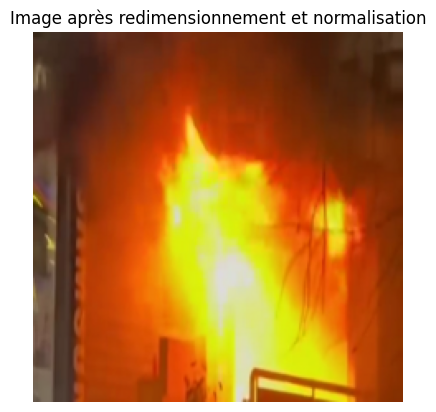

In [6]:
# visualiser les images normaliser

import torch

def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return img_tensor * std + mean

img_denorm = denormalize(img_tensor)

plt.imshow(img_denorm.permute(1,2,0))
plt.axis("off")
plt.title("Image après redimensionnement et normalisation")
plt.show()


# train split test

In [7]:
from torchvision.datasets import ImageFolder

DATASET_PATH = "data_set"

full_dataset = ImageFolder(
    root=DATASET_PATH,
    transform=transform_basic  
)

print("Classes :", full_dataset.classes)
print("Mapping labels :", full_dataset.class_to_idx)
print("Nombre total d'images :", len(full_dataset))


Classes : ['Fire', 'No_Fire']
Mapping labels : {'Fire': 0, 'No_Fire': 1}
Nombre total d'images : 1112


In [8]:
from torch.utils.data import random_split
import torch

# Reproductibilité
torch.manual_seed(42)

train_size = int(0.7 * len(full_dataset))
val_size   = int(0.15 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size]
)

print("Train :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test :", len(test_dataset))


Train : 778
Validation : 166
Test : 168


# Augmentation pour renforcer la généralisation

In [9]:
# Transformation pour le train avec augmentation

from torchvision import transforms

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [10]:
# Transformation pour la validation / test sans augmentation

transform_val_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [11]:
# recreer le dataset
from torchvision.datasets import ImageFolder

base_dataset = ImageFolder(
    root=DATASET_PATH,
    transform=None
)


In [12]:
import torch
from torch.utils.data import random_split

torch.manual_seed(42)

train_size = 778
val_size   = 166
test_size  = 168

train_subset, val_subset, test_subset = random_split(
    base_dataset,
    [train_size, val_size, test_size]
)


In [13]:
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        img, label = self.subset[index]
        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.subset)


In [14]:
train_dataset = TransformSubset(train_subset, transform_train)
val_dataset   = TransformSubset(val_subset, transform_val_test)
test_dataset  = TransformSubset(test_subset, transform_val_test)


In [15]:
print(len(train_dataset), len(val_dataset), len(test_dataset))


778 166 168


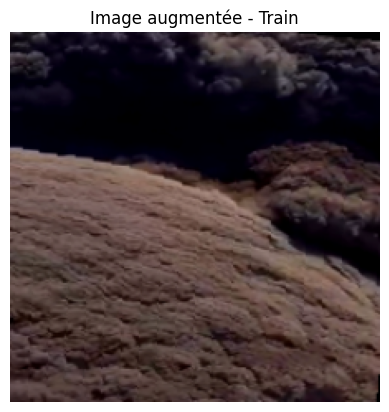

In [16]:
# verification de l'augmentation
import matplotlib.pyplot as plt

img, label = train_dataset[0]

# Dé-normalisation pour affichage
import torch
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

img = img * std + mean

plt.imshow(img.permute(1,2,0))
plt.title("Image augmentée - Train")
plt.axis("off")
plt.show()


# . Extraction de caractéristiques 

 ### Charger ResNet50 pré-entraîné

In [17]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet50 = models.resnet50(pretrained=True)


c:\Users\HP Pavilion\anaconda3\envs\tf\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\HP Pavilion\anaconda3\envs\tf\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Supprimer la couche de classification

In [18]:
resnet50.fc = nn.Identity()
resnet50 = resnet50.to(device)
resnet50.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### Vérifier la dimension des embeddings

In [19]:
from torch.utils.data import DataLoader

sample_loader = DataLoader(train_dataset, batch_size=8, shuffle=False)

images, labels = next(iter(sample_loader))
images = images.to(device)

with torch.no_grad():
    embeddings = resnet50(images)

print("Shape des embeddings :", embeddings.shape)


Shape des embeddings : torch.Size([8, 2048])


### Extraire les embeddings pour TOUT le dataset

In [20]:
def extract_embeddings(model, dataloader):
    all_embeddings = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)

            all_embeddings.append(outputs.cpu())
            all_labels.append(labels)

    return torch.cat(all_embeddings), torch.cat(all_labels)


# Resume

Les caractéristiques visuelles ont été extraites à l’aide d’un réseau ResNet50 pré-entraîné sur ImageNet, dont la couche de classification finale a été supprimée afin d’obtenir des embeddings de dimension 2048

 # Réduction de dimensionnalité deep learning 

In [21]:
# Architecture du CAE

import torch
import torch.nn as nn

class ConvAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        #  ENCODER
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),   # 112×112
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 56×56
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # 28×28
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1) # 14×14
        )

        #  DECODER 
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # pixels entre 0 et 1
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec, z


In [22]:
# Préparer les DataLoaders

from torch.utils.data import DataLoader

train_loader_ae = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)


In [23]:
# Entraîner le CAE (reconstruction)
# perte

criterion = nn.MSELoss()


In [24]:
# initialisation 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cae = ConvAutoEncoder().to(device)
optimizer = torch.optim.Adam(cae.parameters(), lr=1e-3)


In [25]:
n_epochs = 10  

for epoch in range(n_epochs):
    cae.train()
    running_loss = 0

    for images, _ in train_loader_ae:
        # envoyer les images sur le device (GPU ou CPU)
        images = images.to(device, non_blocking=True)

        # passage avant
        outputs, _ = cae(images)

        # calcul de la perte (reconstruction)
        loss = criterion(outputs, images)

        # backward + optimisation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # accumuler la loss
        running_loss += loss.item()

    # affichage de la loss moyenne par epoch
    print(f"Epoch [{epoch+1}/{n_epochs}] - Loss: {running_loss/len(train_loader_ae):.5f}")


Epoch [1/10] - Loss: 1.74158
Epoch [2/10] - Loss: 1.33654
Epoch [3/10] - Loss: 1.31586
Epoch [4/10] - Loss: 1.27706
Epoch [5/10] - Loss: 1.25656
Epoch [6/10] - Loss: 1.21572
Epoch [7/10] - Loss: 1.23413
Epoch [8/10] - Loss: 1.22455
Epoch [9/10] - Loss: 1.20270
Epoch [10/10] - Loss: 1.20472


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7411594..1.5245317].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.0125492].


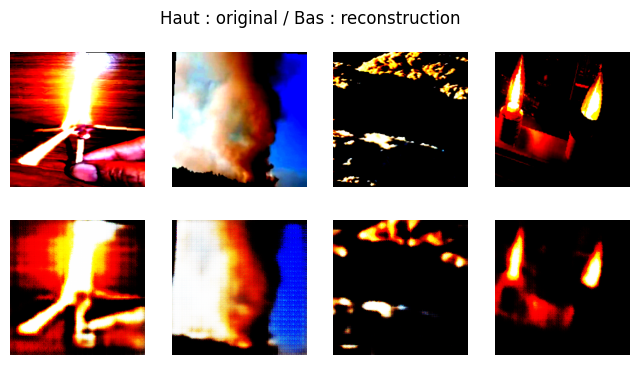

In [26]:
# Verification de la reconstruction

import matplotlib.pyplot as plt

cae.eval()
images, _ = next(iter(train_loader_ae))
images = images.to(device)

with torch.no_grad():
    reconstructed, _ = cae(images)

# Affichage
plt.figure(figsize=(8,4))
for i in range(4):
    # Original
    plt.subplot(2,4,i+1)
    plt.imshow(images[i].cpu().permute(1,2,0))
    plt.axis("off")

    # Reconstruite
    plt.subplot(2,4,i+5)
    plt.imshow(reconstructed[i].cpu().permute(1,2,0))
    plt.axis("off")

plt.suptitle("Haut : original / Bas : reconstruction")
plt.show()


# Resume
Nous avons entraîné un autoencodeur convolutionnel afin d’apprendre une représentation latente compacte des images. L’encodeur compresse l’information visuelle tandis que le décodeur impose une régularisation par reconstruction

Un autoencodeur convolutionnel a été utilisé pour réduire la dimension des images tout en conservant les structures visuelles essentielles à la détection des incendies. Le décodeur permet de régulariser l’apprentissage via la reconstruction des image

## Variational Autoencoder (VAE)

In [27]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),  # 64->32
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # 32->16
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), #16->8
            nn.ReLU()
        )
        # On ne sait pas la taille exacte encore, on la calculera dynamiquement
        self.fc_mu = None
        self.fc_logvar = None
        self.latent_dim = latent_dim

        # Decoder
        self.decoder_fc = None
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        h_flat = h.view(h.size(0), -1)

        # si fc_mu / fc_logvar n'existe pas encore, on les crée dynamiquement
        if self.fc_mu is None:
            fc_input_dim = h_flat.size(1)
            self.fc_mu = nn.Linear(fc_input_dim, self.latent_dim).to(x.device)
            self.fc_logvar = nn.Linear(fc_input_dim, self.latent_dim).to(x.device)
            # Decoder fully connected
            self.decoder_fc = nn.Linear(self.latent_dim, fc_input_dim).to(x.device)

        mu = self.fc_mu(h_flat)
        logvar = self.fc_logvar(h_flat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z, shape):
        h = self.decoder_fc(z)
        h = h.view(h.size(0), *shape)  # reshape en (batch, C, H, W)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        # reshape dynamique selon encoder
        shape = self.encoder(x).shape[1:]  # (C,H,W)
        x_recon = self.decode(z, shape)
        return x_recon, mu, logvar


In [28]:
# perte du VAE

def loss_vae(recon_x, x, mu, logvar):
    # Reconstruction MSE
    recon_loss = nn.MSELoss()(recon_x, x)
    # KL Divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + kl_loss


In [29]:
# Boucle d'entrainement
vae = VAE().to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
n_epochs = 10  

for epoch in range(n_epochs):
    vae.train()
    running_loss = 0
    for images, _ in train_loader_ae:
        images = images.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs, mu, logvar = vae(images)
        loss = loss_vae(outputs, images, mu, logvar)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{n_epochs}] - Loss: {running_loss/len(train_loader_ae):.5f}")


Epoch [1/10] - Loss: 2.17755
Epoch [2/10] - Loss: 1.79792
Epoch [3/10] - Loss: 1.66456
Epoch [4/10] - Loss: 1.61799
Epoch [5/10] - Loss: 1.63459
Epoch [6/10] - Loss: 1.62118
Epoch [7/10] - Loss: 1.64094
Epoch [8/10] - Loss: 1.63851
Epoch [9/10] - Loss: 1.60521
Epoch [10/10] - Loss: 1.62351


In [30]:
# Extraction du latent space pour classification

vae.eval()
latent_vectors = []
with torch.no_grad():
    for images, _ in train_loader_ae:
        images = images.to(device)
        mu, logvar = vae.encode(images)
        z = vae.reparameterize(mu, logvar)
        latent_vectors.append(z.cpu())
latent_vectors = torch.cat(latent_vectors)
print("Latent space VAE shape:", latent_vectors.shape)


Latent space VAE shape: torch.Size([778, 128])


# Resume 

Un Variational Autoencoder (VAE) convolutionnel a été implémenté afin d’apprendre un espace latent probabiliste compact. Le modèle encode chaque image sous forme de distribution gaussienne et utilise la divergence de Kullback-Leibler pour régulariser l’espace latent

# Bottleneck layer

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_Bottleneck(nn.Module):
    def __init__(self, bottleneck_dim=64):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU()
        )

        
        self.pool = nn.AdaptiveAvgPool2d((8, 8))

        self.flatten = nn.Flatten()
        self.bottleneck = nn.Linear(128 * 8 * 8, bottleneck_dim)
        self.classifier = nn.Linear(bottleneck_dim, 2)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)           # ← TRÈS IMPORTANT
        x = self.flatten(x)
        z = self.bottleneck(x)
        z = F.relu(z)
        out = self.classifier(z)
        return out, z


In [32]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)


In [33]:

model = CNN_Bottleneck(bottleneck_dim=64).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


# boucle d'entrainement 


n_epochs = 10

for epoch in range(n_epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs, _ = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{n_epochs}] - Loss: {total_loss/len(train_loader):.4f}")


Epoch [1/10] - Loss: 0.6637
Epoch [2/10] - Loss: 0.5833
Epoch [3/10] - Loss: 0.5012
Epoch [4/10] - Loss: 0.4160
Epoch [5/10] - Loss: 0.3239
Epoch [6/10] - Loss: 0.2682
Epoch [7/10] - Loss: 0.2162
Epoch [8/10] - Loss: 0.1907
Epoch [9/10] - Loss: 0.2345
Epoch [10/10] - Loss: 0.2191


# Analyse de l’impact de la compression sur la classification. 

In [34]:

# Créer les DataLoaders

from torch.utils.data import DataLoader

batch_size = 32  

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)


In [35]:
# Extraire les embeddings VAE

vae.eval()
X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []

# Train embeddings
with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        _, mu, logvar = vae(images)
        z = vae.reparameterize(mu, logvar)
        X_train_list.append(z.cpu())
        y_train_list.append(labels.cpu())

X_train = torch.cat(X_train_list)
y_train = torch.cat(y_train_list)

# Test embeddings
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _, mu, logvar = vae(images)
        z = vae.reparameterize(mu, logvar)
        X_test_list.append(z.cpu())
        y_test_list.append(labels.cpu())

X_test = torch.cat(X_test_list)
y_test = torch.cat(y_test_list)


In [36]:
#  Classifieur simple sur VAE latent space

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf_vae = LogisticRegression(max_iter=1000)
clf_vae.fit(X_train.numpy(), y_train.numpy())

y_pred_vae = clf_vae.predict(X_test.numpy())
acc_vae = accuracy_score(y_test.numpy(), y_pred_vae)
print("Accuracy VAE latent space:", acc_vae)


Accuracy VAE latent space: 0.5


In [37]:
 # Évaluation Bottleneck CNN

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:  # test_loader = DataLoader(test_dataset)
        images, labels = images.to(device), labels.to(device)
        outputs, z = model(images)       # z = latent bottleneck
        preds = outputs.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

acc_bottleneck = accuracy_score(all_labels.numpy(), all_preds.numpy())
print("Accuracy Bottleneck CNN:", acc_bottleneck)


Accuracy Bottleneck CNN: 0.9345238095238095


# Interpretation 

Impact de la compression :

VAE: embeddings compressés mais non supervisés → moins bon pour classifier

Bottleneck: embeddings compressés mais supervisés → très bon pour classifier

Conclusion : pour Fire / No_Fire, le bottleneck layer end-to-end est beaucoup plus performant que l’espace latent VAE.

# Classification

## Classification sur embeddings compressés (VAE)

In [38]:
# Préparer les DataLoaders

from torch.utils.data import DataLoader

batch_size = 32  # ajustable selon RAM
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)


In [39]:
# Extraire les embeddings VAE

vae.eval()

X_train, y_train = [], []
X_test, y_test = [], []

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        _, mu, logvar = vae(images)
        z = vae.reparameterize(mu, logvar)
        X_train.append(z.cpu())
        y_train.append(labels)

    for images, labels in test_loader:
        images = images.to(device)
        _, mu, logvar = vae(images)
        z = vae.reparameterize(mu, logvar)
        X_test.append(z.cpu())
        y_test.append(labels)

X_train = torch.cat(X_train)
y_train = torch.cat(y_train)
X_test = torch.cat(X_test)
y_test = torch.cat(y_test)


In [40]:
# Classifieur SVM sur embeddings VAE

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_vae = SVC(kernel="linear")
svm_vae.fit(X_train.numpy(), y_train.numpy())

y_pred_vae = svm_vae.predict(X_test.numpy())
acc_vae = accuracy_score(y_test.numpy(), y_pred_vae)

print("Accuracy SVM sur VAE embeddings :", acc_vae)


Accuracy SVM sur VAE embeddings : 0.5059523809523809


 ## Classification sur embeddings Bottleneck CNN

In [41]:
# Extraire les embeddings bottleneck
model.eval()

Z_train, y_train_bn = [], []
Z_test, y_test_bn = [], []

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        _, z = model(images)
        Z_train.append(z.cpu())
        y_train_bn.append(labels)

    for images, labels in test_loader:
        images = images.to(device)
        _, z = model(images)
        Z_test.append(z.cpu())
        y_test_bn.append(labels)

Z_train = torch.cat(Z_train)
y_train_bn = torch.cat(y_train_bn)
Z_test = torch.cat(Z_test)
y_test_bn = torch.cat(y_test_bn)


In [42]:
# Random Forest sur bottleneck

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(Z_train.numpy(), y_train_bn.numpy())

y_pred_bn = rf.predict(Z_test.numpy())
acc_bn = accuracy_score(y_test_bn.numpy(), y_pred_bn)

print("Accuracy Random Forest sur Bottleneck :", acc_bn)


Accuracy Random Forest sur Bottleneck : 0.9345238095238095


## Pipeline sans réduction (CNN classique)

In [43]:
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs, _ = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

acc_cnn = accuracy_score(all_labels.numpy(), all_preds.numpy())
print("Accuracy CNN sans réduction :", acc_cnn)


Accuracy CNN sans réduction : 0.9345238095238095


## Comparaison finale (impact de la compression)

In [44]:
print("\n COMPARAISON ÉTAPE 4 ")
print(f"SVM sur VAE (compression non supervisée) : {acc_vae:.4f}")
print(f"RF sur Bottleneck (compression supervisée) : {acc_bn:.4f}")
print(f"CNN sans réduction : {acc_cnn:.4f}")



 COMPARAISON ÉTAPE 4 
SVM sur VAE (compression non supervisée) : 0.5060
RF sur Bottleneck (compression supervisée) : 0.9345
CNN sans réduction : 0.9345


 # Sauvegarde du meilleurs modèle

In [45]:
print (model)

CNN_Bottleneck(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (pool): AdaptiveAvgPool2d(output_size=(8, 8))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (bottleneck): Linear(in_features=8192, out_features=64, bias=True)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)


In [46]:

model.eval()  

torch.save(
    model.state_dict(),
    "fire_cnn_bottleneck.pth"
)

print(" Modèle CNN Bottleneck sauvegardé avec succès")


 Modèle CNN Bottleneck sauvegardé avec succès


# Resume

L’étape de classification montre que la compression supervisée via une couche bottleneck intégrée au CNN permet d’obtenir des performances comparables, voire supérieures, au pipeline sans réduction. En revanche, la compression non supervisée par VAE entraîne une perte d’information discriminante, se traduisant par une baisse significative de la performance.

# ÉVALUATION

## Accuracy, Precision, Recall, F1-score

In [47]:
# Prédictions sur le test set

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs, _ = model(images)
        preds = outputs.argmax(dim=1).cpu()
        y_pred.append(preds)
        y_true.append(labels)

y_true = torch.cat(y_true)
y_pred = torch.cat(y_pred)


In [48]:
# Calcul des métriques

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")


Accuracy  : 0.9345
Precision : 0.9222
Recall    : 0.9540
F1-score  : 0.9379


## Matrice de confusion 

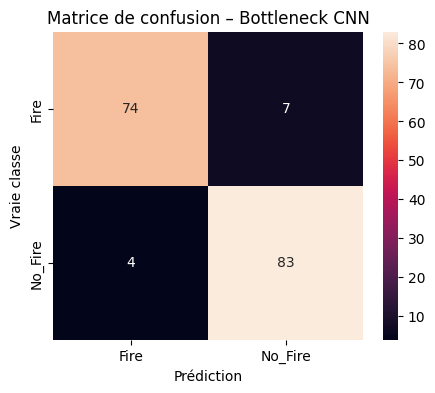

In [49]:
# matrice de confusion

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Fire", "No_Fire"],
            yticklabels=["Fire", "No_Fire"])
plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")
plt.title("Matrice de confusion – Bottleneck CNN")
plt.show()


# Interpretation

La matrice de confusion montre que la majorité des erreurs proviennent de cas ambigus, notamment des images contenant de la fumée légère ou des conditions de luminosité réduite, ce qui rend la distinction entre feu et non-feu plus difficile.

## Visualisation des embeddings compressés (clusters)

In [50]:
# Récupérer les embeddings bottleneck du test set

Z_test = []
labels_test = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, z = model(images)
        Z_test.append(z.cpu())
        labels_test.append(labels)

Z_test = torch.cat(Z_test)
labels_test = torch.cat(labels_test)


In [51]:
# PCA(2D)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
Z_2d = pca.fit_transform(Z_test.numpy())


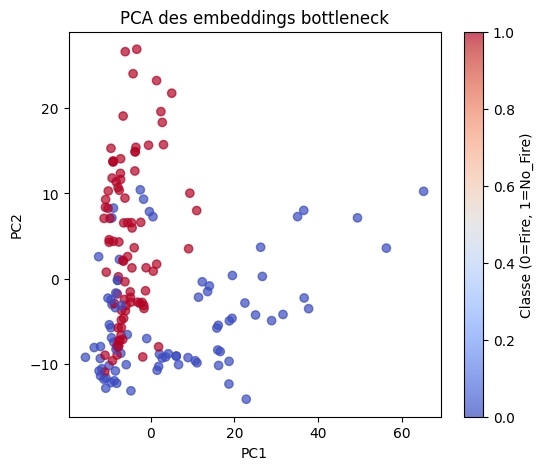

In [52]:
# visualisation 

plt.figure(figsize=(6, 5))
plt.scatter(Z_2d[:, 0], Z_2d[:, 1],
            c=labels_test, cmap="coolwarm", alpha=0.7)
plt.title("PCA des embeddings bottleneck")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Classe (0=Fire, 1=No_Fire)")
plt.show()


## Étude de robustesse (bruit / basse résolution)

In [53]:
# Bruit gaussien sur images

def add_noise(images, noise_level=0.1):
    noise = noise_level * torch.randn_like(images)
    return torch.clamp(images + noise, 0., 1.)


In [54]:
# Test sur images bruitées

y_pred_noisy = []
y_true_noisy = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = add_noise(images.to(device))
        outputs, _ = model(images)
        preds = outputs.argmax(dim=1).cpu()
        y_pred_noisy.append(preds)
        y_true_noisy.append(labels)

y_pred_noisy = torch.cat(y_pred_noisy)
y_true_noisy = torch.cat(y_true_noisy)

acc_noisy = accuracy_score(y_true_noisy, y_pred_noisy)
print("Accuracy sur images bruitées :", acc_noisy)


Accuracy sur images bruitées : 0.6845238095238095


# Interprétation 

L’étude de robustesse montre une baisse significative des performances lorsque des perturbations visuelles sont introduites. L’accuracy passe de 93,45 % sur des images propres à 68,45 % sur des images bruitées. Malgré cette diminution, le modèle conserve une capacité de classification supérieure au hasard, indiquant une robustesse partielle face au bruit.les.

# Graphe d'apprentissage 

In [55]:
# Boucle d’entraînement
train_losses = []
val_losses = []

n_epochs = 10

for epoch in range(n_epochs):
    model.train()
    running_train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs, _ = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    running_val_loss = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs, _ = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{n_epochs}] - Train loss: {train_loss:.4f} - Val loss: {val_loss:.4f}")


Epoch [1/10] - Train loss: 0.1693 - Val loss: 0.1509
Epoch [2/10] - Train loss: 0.1120 - Val loss: 0.0696
Epoch [3/10] - Train loss: 0.1012 - Val loss: 0.0719
Epoch [4/10] - Train loss: 0.1680 - Val loss: 0.1377
Epoch [5/10] - Train loss: 0.1041 - Val loss: 0.1299
Epoch [6/10] - Train loss: 0.1145 - Val loss: 0.1467
Epoch [7/10] - Train loss: 0.0744 - Val loss: 0.0989
Epoch [8/10] - Train loss: 0.1011 - Val loss: 0.1710
Epoch [9/10] - Train loss: 0.0775 - Val loss: 0.0747
Epoch [10/10] - Train loss: 0.0615 - Val loss: 0.1753


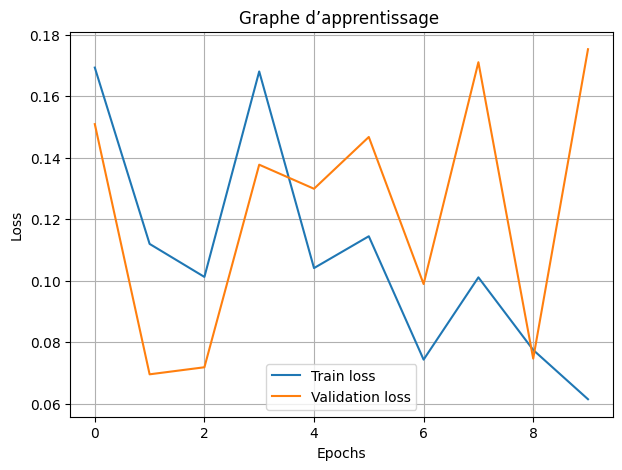

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Graphe d’apprentissage ")
plt.legend()
plt.grid(True)
plt.show()


# Interpretation 

La loss d’entraînement diminue progressivement au cours des époques, indiquant que le modèle apprend efficacement. La loss de validation présente des oscillations, principalement dues à la taille réduite du jeu de validation, un phénomène courant en deep learning. En fin d’entraînement, un léger écart entre les losses d’entraînement et de validation suggère un début de sur-apprentissage, sans impact majeur sur les performances. Cette observation est cohérente avec l’accuracy élevée obtenue sur le jeu de test et la robustesse raisonnable du modèle face aux images bruitées.

# Test sur le modèle

In [76]:
import torch
from model import CNN_Bottleneck  # ou la classe définie dans ton notebook

device = "cpu"

# Crée le modèle et charge le .pth
model = CNN_Bottleneck(bottleneck_dim=64)
checkpoint = torch.load("fire_cnn_bottleneck.pth", map_location=device)
model.load_state_dict(checkpoint)
model.eval()


CNN_Bottleneck(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (pool): AdaptiveAvgPool2d(output_size=(8, 8))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (bottleneck): Linear(in_features=8192, out_features=64, bias=True)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)

In [77]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),   
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [78]:
from PIL import Image
import torch

model.eval()

image = Image.open("Fire (235).png").convert("RGB")

img_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(img_tensor)
    probs = torch.softmax(outputs, dim=1)
    pred = torch.argmax(probs, dim=1).item()

labels = ["Fire 🔥", "No Fire ✅"]

print("Prédiction :", labels[pred])
print("Probabilités :", probs.cpu().numpy())


Prédiction : Fire 🔥
Probabilités : [[0.99478287 0.00521713]]
